In [1]:
import numpy as np
import pandas as pd
import time
import os
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import seaborn as sns
from tqdm.auto import tqdm, trange
from vscodenb import prange, pqdm, set_vscode_theme
set_vscode_theme()
from geneinfo.plot import ChromIdeogram, GenomeIdeogram
from geneinfo.utils import dummy_segments
plt.rcParams['axes.grid'] = False
%config InlineBackend.figure_format = 'svg'


0.0


In [2]:
import requests, sys

def lift(from_assem, to_assem, chrom, pos):
    server = "https://rest.ensembl.org"
    ext = f"/map/human/{from_assem}/{chrom}:{int(pos)}..{int(pos+1)}:1/{to_assem}?"
    r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
    if not r.ok:
      r.raise_for_status()
      sys.exit()
    decoded = r.json()
    return decoded['mappings'][0]['mapped']['start']

# pos = 1000000
# tup = ('X', pos, pos)
# pos = liftover('GRCh37', 'GRCh38', tup[0].replace('chr', ''), tup[1])
# tup = ('X', pos, pos)
# pos = liftover('GRCh38', 'GRCh37', tup[0].replace('chr', ''), tup[1])
# pos


In [3]:
lifted_superloops_file = '../results/chrX_superloops.csv'
if not os.path.exists(lifted_superloops_file):
    chrX_superloops = pd.read_csv('../data/superloops_and_ctcf/GSE63525_GM12878_HiCCUPS_chrX_superloop_list.txt', sep='\t')

    assert np.all(chrX_superloops.chr1 == chrX_superloops.chr2)

    chrX_superloops['x'] = (chrX_superloops.x2 + chrX_superloops.x1 ) // 2 
    chrX_superloops['y'] = (chrX_superloops.y2 + chrX_superloops.y1 ) // 2 

    chrX_superloops['x_hg38'] = [
        lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), pos) for (chrom, pos) in zip(chrX_superloops.chr1, chrX_superloops.x)
            ]
    chrX_superloops['y_hg38'] = [
        lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), pos) for (chrom, pos) in zip(chrX_superloops.chr1, chrX_superloops.y)
            ]
    chrX_superloops.to_csv(lifted_superloops_file, index=False)

chrX_superloops = pd.read_csv(lifted_superloops_file)
chrX_superloops.head()

,chr1,x1,x2,chr2,y1,y2,color,o,e_bl,e_donut,...,fdr_h,fdr_v,num_collapsed,centroid1,centroid2,radius,x,y,x_hg38,y_hg38
0,X,115000000,115050000,X,130850000,130900000,"0,255,255",619,59.8216,47.1159,...,0.000000e+00,7,115046428,130889285,88352.263406,NaN,115025000,130875000,115908667,131740972
1,X,130900000,130950000,X,153750000,153800000,"0,255,255",393,43.3405,40.5877,...,2.751172e-198,4,130900000,153775000,75000.000000,NaN,130925000,153775000,131790972,154546785
2,X,47050000,47100000,X,56750000,56800000,"0,255,255",197,64.0441,60.3381,...,1.302654e-24,2,47075000,56800000,25000.000000,NaN,47075000,56775000,47215601,56748567
3,X,56800000,56850000,X,75350000,75400000,"0,255,255",194,38.0710,31.1849,...,8.672975e-49,3,56808333,75358333,37267.799625,NaN,56825000,75375000,56798567,76155165
4,X,130900000,130950000,X,137800000,137850000,"0,255,255",170,68.6131,74.5768,...,1.254676e-07,3,130925000,137825000,50000.000000,NaN,130925000,137825000,131790972,138742838


In [4]:
chrX_superloop_coords = [(f'chr{c}', s, e) for c, s, e in zip(chrX_superloops.chr1, chrX_superloops.x_hg38, chrX_superloops.y_hg38)]

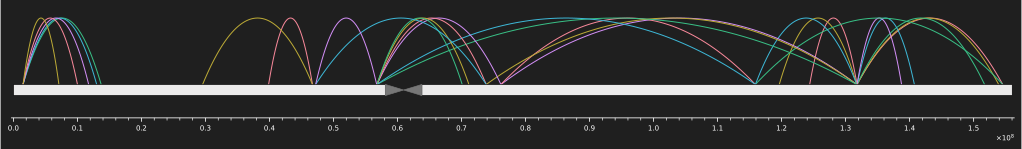

In [5]:
g = ChromIdeogram('chrX', assembly='hg38', axes_width_inches=18)
g.draw_chromosomes(base=2, height=1)
g.add_connections(chrX_superloop_coords, height=6, adjust_heights=False, linewidth=1, alpha=1, zorder=-1, color_cycle=5)

In [6]:
primary_hiccups_loops = pd.read_csv('../data/superloops_and_ctcf/GSE63525_GM12878_primary_HiCCUPS_looplist.txt', sep='\t')
primary_hiccups_loops

,chr1,x1,x2,chr2,y1,y2,color,o,e_bl,e_donut,e_h,e_v,fdr_bl,fdr_donut,fdr_h,fdr_v,num_collapsed,centroid1,centroid2,radius
0,14,24800000,24810000,14,24900000,24910000,"255,255,0",1116,384.070000,324.463000,371.910000,467.494000,3.879291e-116,3.928639e-181,7.338401e-181,1.388378e-115,13,24809615,24898076,28554.940297
1,11,64610000,64620000,11,64660000,64670000,"255,255,0",1067,421.911000,415.013000,440.348000,441.332000,2.640898e-100,1.014661e-99,2.084920e-99,9.451635e-100,1,64615000,64665000,0.000000
2,14,24710000,24720000,14,24760000,24770000,"255,255,0",1001,413.031000,413.759000,420.892000,481.232000,2.680664e-80,7.724544e-80,1.587235e-79,1.546718e-37,6,24711666,24768333,14907.119850
3,11,111230000,111240000,11,111280000,111290000,"255,255,0",979,433.831000,434.323000,404.255000,508.769000,4.151635e-74,1.063401e-73,2.185071e-73,1.007530e-33,4,111235000,111292500,10307.764064
4,1,46500000,46510000,1,46640000,46650000,"255,255,0",943,233.416000,235.092000,330.353000,255.938000,5.684294e-234,6.967297e-234,2.515067e-111,1.415946e-168,11,46502272,46649545,35559.285847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8049,12,25950000,25960000,12,104370000,104380000,"255,255,0",14,0.066886,0.056316,0.064276,0.040160,4.453530e-05,1.399963e-04,1.326262e-04,3.133250e-04,1,25955000,104375000,0.000000
8050,7,66760000,66770000,7,102010000,102020000,"255,255,0",14,0.016930,0.030228,0.161471,0.051110,4.453530e-05,1.399963e-04,1.326262e-04,3.133250e-04,1,66765000,102015000,0.000000
8051,2,87030000,87040000,2,113040000,113050000,"255,255,0",13,0.207832,0.182958,0.236453,1.175160,4.236018e-04,1.328800e-03,1.283456e-03,2.908229e-03,2,87030000,113045000,5000.000000
8052,2,87100000,87110000,2,112630000,112640000,"255,255,0",13,0.003070,0.043600,0.368265,0.020573,4.236018e-04,1.328800e-03,1.283456e-03,2.908229e-03,1,87105000,112635000,0.000000


In [7]:
assert np.all(primary_hiccups_loops.chr1 == primary_hiccups_loops.chr2)

primary_hiccups_loops['x_hg19'] = (primary_hiccups_loops.x2 + primary_hiccups_loops.x1 ) // 2 
primary_hiccups_loops['y_hg19'] = (primary_hiccups_loops.y2 + primary_hiccups_loops.y1 ) // 2 


In [11]:
medium_loops = primary_hiccups_loops.loc[primary_hiccups_loops.y_hg19 - primary_hiccups_loops.x_hg19 > 5e5].copy()
medium_loops.shape

(1818, 22)

In [12]:
medium_loops_file = '../results/medium_loops_lifted.csv'
if not os.path.exists(medium_loops_file):
    x_hg38, y_hg38 = [], []
    loop_coords = list(zip(medium_loops.chr1, medium_loops.x_hg19, medium_loops.y_hg19))
    for chrom, x, y in tqdm(loop_coords):
        try:
            x_hg38.append(lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), x))
            y_hg38.append(lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), y))
        except IndexError:
            print(f'Could not lift loop {i} at {chrom}:{x}-{y}')
            x_hg38.append(np.nan)
            y_hg38.append(np.nan)
        # if not i % 10:
        #     print(f'Lifted {i} loops')
        #     time.sleep(1)  # to avoid overloading the server

    medium_loops['x_hg38'] = x_hg38
    medium_loops['y_hg38'] = y_hg38

    # primary_hiccups_loops['x_hg38'] = [
    #     lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), pos) for (chrom, pos) in zip(primary_hiccups_loops.chr1, primary_hiccups_loops.x)
    #          ]
    # primary_hiccups_loops['y_hg38'] = [
    #     lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), pos) for (chrom, pos) in zip(primary_hiccups_loops.chr1, primary_hiccups_loops.y)
    #          ]
    medium_loops.to_csv(medium_loops_file, index=False)

medium_loops = pd.read_csv(medium_loops_file)
medium_loops.head()

  0%|          | 0/1818 [00:00<?, ?it/s]

NameError: name 'i' is not defined

In [ ]:
medium_loops = pd.read_csv(medium_loops_file)
medium_loops.head()

In [ ]:
chrX_medium_loops = medium_loops.loc[medium_loops.chr1 == 'X'].copy()

In [ ]:
# chrX_medium_loops = primary_hiccups_loops_hg19.loc[(primary_hiccups_loops_hg19.y - primary_hiccups_loops_hg19.x > 2e5) & (primary_hiccups_loops_hg19.chr1 == 'X')].copy()
# chrX_medium_loops.shape

In [ ]:
# chrX_medium_loops_file = '../results/chrX_medium_loops_lifted.csv'
# if not os.path.exists(chrX_medium_loops_file):
#     x_hg38, y_hg38 = [], []
#     for i, (chrom, x, y) in enumerate(zip(chrX_medium_loops.chr1, chrX_medium_loops.x, chrX_medium_loops.y)):
#         try:
#             x_hg38.append(lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), x))
#             y_hg38.append(lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), y))
#         except IndexError:
#             print(f'Could not lift loop {i} at {chrom}:{x}-{y}')
#             x_hg38.append(np.nan)
#             y_hg38.append(np.nan)
#         if not i % 10:
#             print(f'Lifted {i} loops')
#             time.sleep(1)  # to avoid overloading the server

#     chrX_medium_loops['x_hg38'] = x_hg38
#     chrX_medium_loops['y_hg38'] = y_hg38

#     # primary_hiccups_loops_hg19['x_hg38'] = [
#     #     lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), pos) for (chrom, pos) in zip(primary_hiccups_loops_hg19.chr1, primary_hiccups_loops_hg19.x)
#     #          ]
#     # primary_hiccups_loops_hg19['y_hg38'] = [
#     #     lift('GRCh37', 'GRCh38', chrom.replace('chr', ''), pos) for (chrom, pos) in zip(primary_hiccups_loops_hg19.chr1, primary_hiccups_loops_hg19.y)
#     #          ]
#     chrX_medium_loops.to_csv(chrX_medium_loops_file, index=False)

# chrX_medium_loops = pd.read_csv(chrX_medium_loops_file)
# chrX_medium_loops.head()

Lifted 0 loops
Lifted 10 loops
Lifted 20 loops
Lifted 30 loops
Lifted 40 loops
Lifted 50 loops
Lifted 60 loops
Lifted 70 loops
Lifted 80 loops
Lifted 90 loops
Lifted 100 loops
Lifted 110 loops
Lifted 120 loops
Lifted 130 loops
Lifted 140 loops


,chr1,x1,x2,chr2,y1,y2,color,o,e_bl,e_donut,...,fdr_h,fdr_v,num_collapsed,centroid1,centroid2,radius,x,y,x_hg38,y_hg38
0,X,109400000,109410000,X,109650000,109660000,"255,255,0",373,75.1110,61.4951,...,3.541644e-90,2.359688e-90,9,109405000,109655000,14142.135624,109405000,109655000,110161772,110411772
1,X,11550000,11560000,X,11780000,11790000,"255,255,0",318,90.5854,69.8761,...,3.397524e-42,6.668202e-62,6,11553333,11786666,11785.113020,11555000,11785000,11536880,11766881
2,X,13110000,13120000,X,13500000,13510000,"255,255,0",231,68.0926,51.2989,...,3.266999e-54,2.606271e-25,7,13116428,13503571,18626.292586,13115000,13505000,13096881,13486881
3,X,23710000,23720000,X,23920000,23930000,"255,255,0",202,59.3197,52.4585,...,1.285832e-26,1.292928e-26,6,23708333,23916666,13437.096247,23715000,23925000,23696883,23906883
4,X,109690000,109700000,X,110090000,110100000,"255,255,0",200,54.1323,43.2239,...,4.070147e-38,4.396954e-38,8,109693750,110090000,17365.554987,109695000,110095000,110451772,110851772


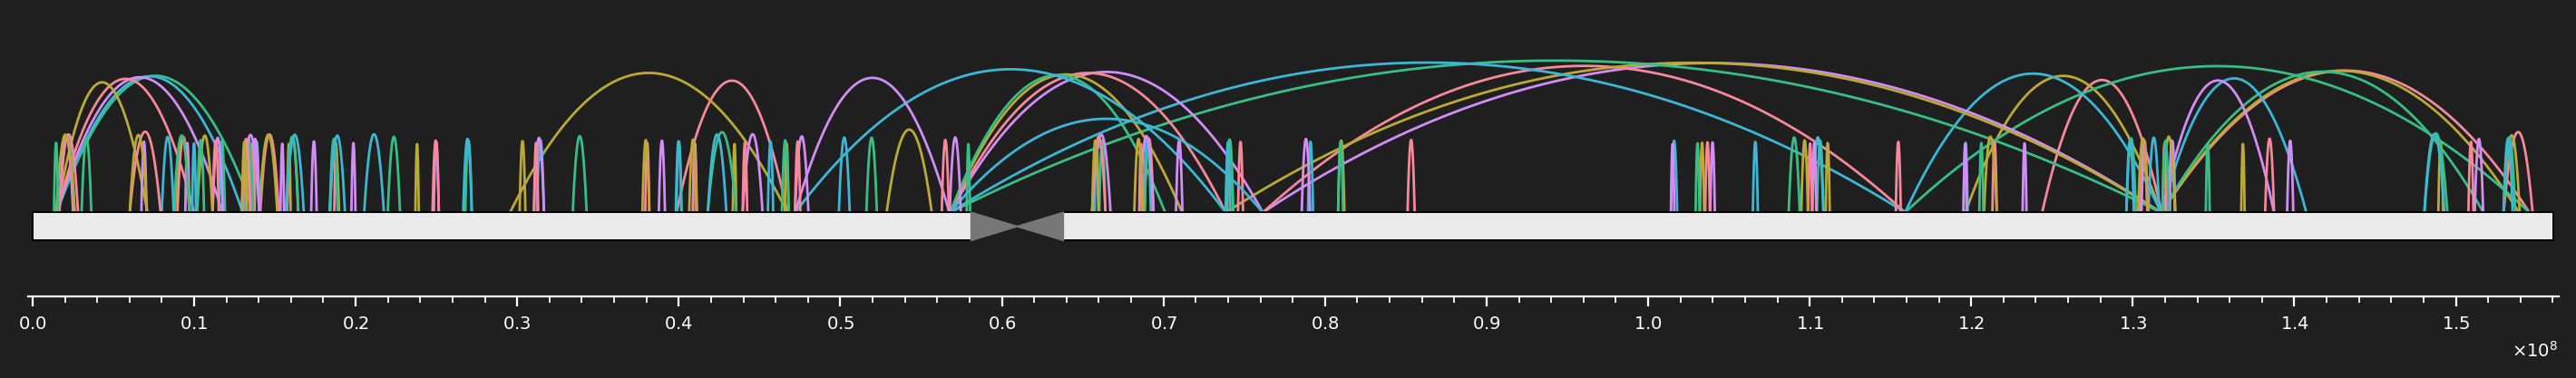

In [17]:
chrX_medium_loop_coords = [(f'chr{c}', s, e) for c, s, e in zip(chrX_medium_loops.chr1, chrX_medium_loops.x_hg38, chrX_medium_loops.y_hg38)]

g = ChromIdeogram('chrX', assembly='hg38',
                  axes_width_inches=18,
                #   zooms=[(1_000_000, 3_000_000), (45_000_000, 48_000_000), (56_000_000, 59_000_000), (73_000_000, 76_000_000), (113_000_000, 116_000_000), (130_000_000, 133_000_000), (152_000_000, 155_000_000)],
                #   zoom_effect_color='gray',
                #   zoom_effect_alpha=0.2
                  )
g.draw_chromosomes(base=2, height=1)
g.add_connections(chrX_superloop_coords, height=6, linewidth=1, zorder=-1, color_cycle=5)
g.add_connections(chrX_medium_loop_coords, height=4, linewidth=1, zorder=-1, color_cycle=5)

NameError: name 'loop_coords' is not defined

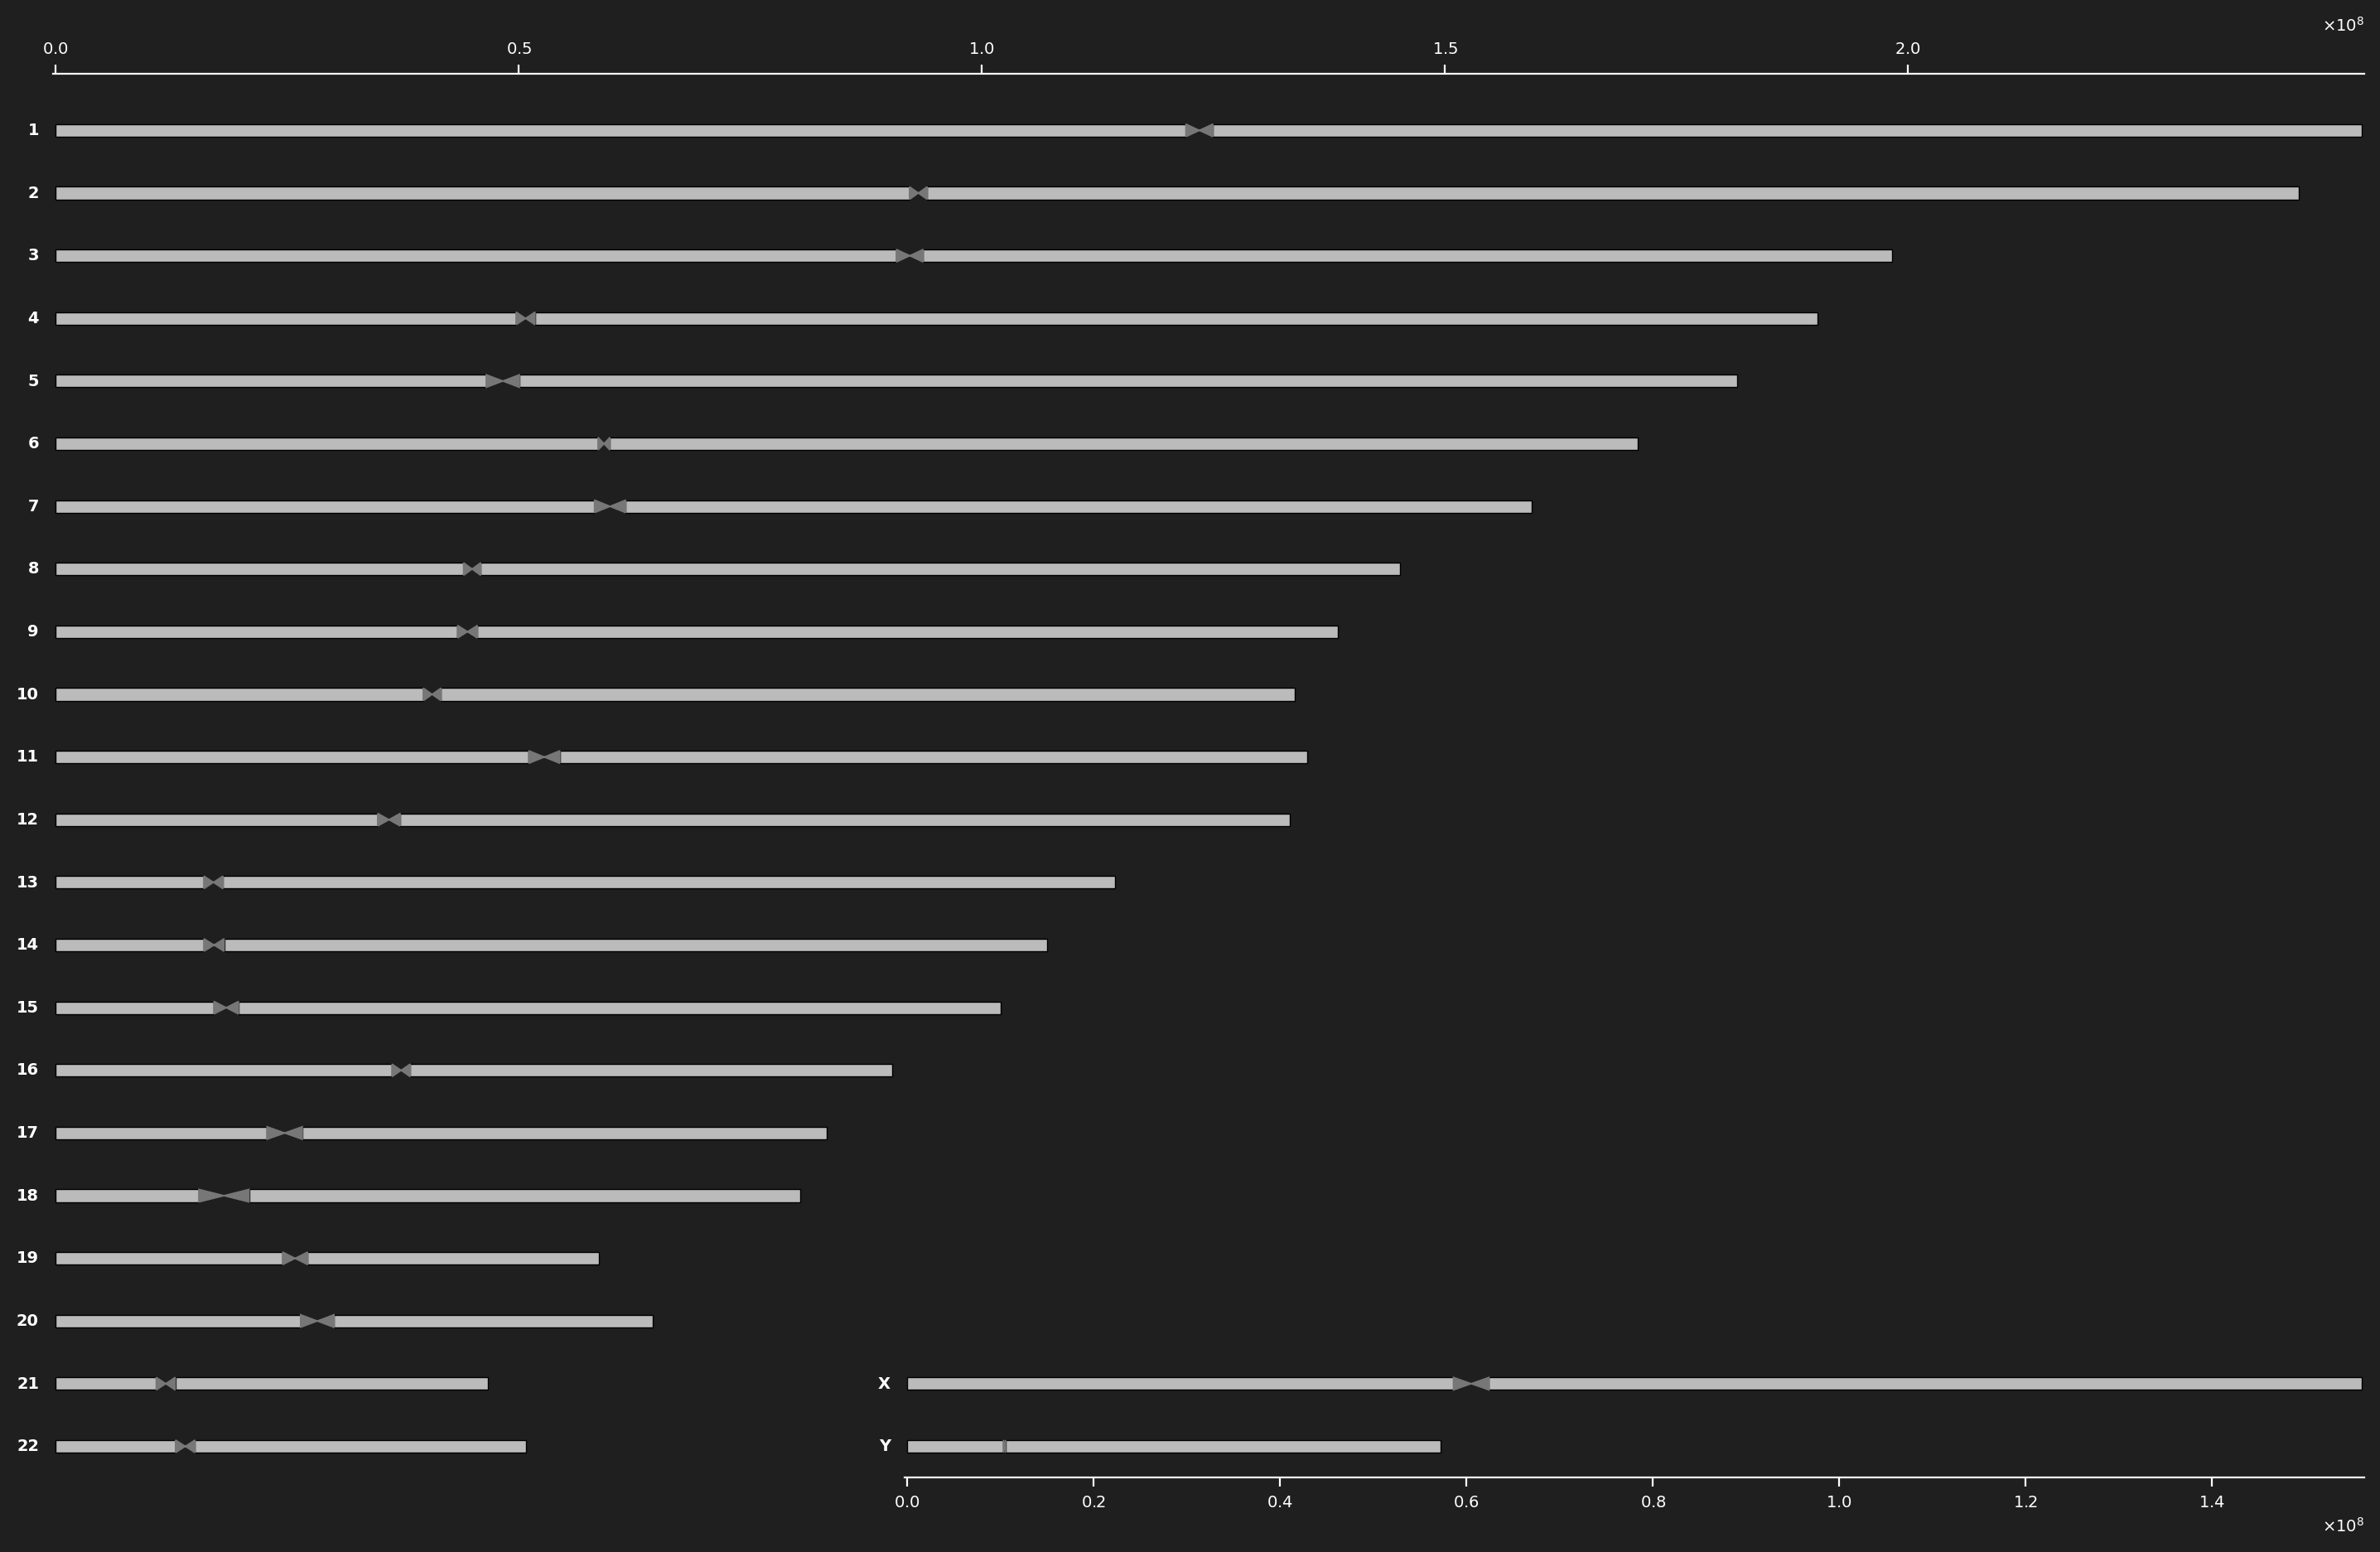

In [18]:

g = GenomeIdeogram(assembly='hg38', axes_height_inches=0.5, axes_width_inches=18) 
g.draw_chromosomes(facecolor='#bbbbbb', edgecolor='black', linewidth=0.5)
g.add_connections(loop_coords, linewidth=0.5, color_cycle=10)


In [ ]:
chrX_loops = [x for x in loop_coords if x[0] == 'chrX']

In [ ]:
g = ChromIdeogram('chrX', assembly='hg38', axes_width_inches=18)
g.draw_chromosomes(base=2, height=1)
g.add_connections(chrX_superloop_coords, height=6, adjust_heights=False, linewidth=1, alpha=0.5, zorder=-1, color_cycle=5)
g.add_connections(chrX_loops, height=3, adjust_heights=False, linewidth=1, alpha=0.5, zorder=-1, color_cycle=5)